In [1]:
import pandas as pd

df_prc = pd.read_pickle("C:/Users/hp/Downloads/TER_M1_2025/data/ENQUETE_PRC_BC")
print(" Données PRC ")
print("Nombre de lignes :", len(df_prc))
print("Colonnes :", df_prc.columns.tolist())
print(df_prc.head(), "\n")
## ca prend presque 10 mins pour le loading de l'excel vu sa grande taille désolé :/
df_soins = pd.read_excel("C:/Users/hp/Downloads/TER_M1_2025/data/df_all_care_T0_no_filtered.xlsx")
print(" Données de Soins ")
print("Nombre de lignes :", len(df_soins))
print("Colonnes :", df_soins.columns.tolist())
print(df_soins.head())


 Données PRC 
Nombre de lignes : 930
Colonnes : ['ID_PATIENT', 'peur_recidive1']
   ID_PATIENT  peur_recidive1
0  1101100325               2
1  1101100717               3
2  1101100766               1
3  1102100494               2
4  1102101103               3 

 Données de Soins 
Nombre de lignes : 485287
Colonnes : ['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen', 'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire', 'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner', 'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns', 'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan', 'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore', 'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen', 'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part', 'SURG', 'T0', 'TREATMENT_TYPE']
   ID_PATIENT     CODE  DAYS_SINCE_DIAG TABLE_ORIGIN  Cons_Med_Gen  Cons_Spe  \
0  3104503184  D01AC12                0   

In [45]:
df_prc = pd.read_pickle("C:/Users/hp/Downloads/TER_M1_2025/data/ENQUETE_PRC_BC")
print(" Données PRC ")
print("Nombre de lignes :", len(df_prc))
print("Colonnes :", df_prc.columns.tolist())
print(df_prc.head(), "\n")

 Données PRC 
Nombre de lignes : 930
Colonnes : ['ID_PATIENT', 'peur_recidive1']
   ID_PATIENT  peur_recidive1
0  1101100325               2
1  1101100717               3
2  1101100766               1
3  1102100494               2
4  1102101103               3 



In [3]:
df_soins.to_csv("df_soins.csv", index=False)


In [2]:
df_soins = pd.read_csv("df_soins.csv")
df_soins.columns


Index(['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen',
       'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire',
       'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner',
       'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns',
       'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan',
       'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore',
       'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen',
       'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part',
       'SURG', 'T0', 'TREATMENT_TYPE'],
      dtype='object')

In [46]:
def recoder_prc(classe):
    if classe in [1, 2]:
        return 0  
    elif classe == 3:
        return 1  
    else:
        return None  

df_prc['PRC'] = df_prc['peur_recidive1'].apply(recoder_prc)

In [47]:
df_prc.head(20)

,ID_PATIENT,peur_recidive1,PRC
0,1101100325,2,0
1,1101100717,3,1
2,1101100766,1,0
3,1102100494,2,0
4,1102101103,3,1
5,1102101659,2,0
6,1102102186,3,1
7,1103100275,1,0
8,1103101510,1,0
9,1103102437,2,0


In [48]:
df_prc = df_prc[['ID_PATIENT', 'PRC']]


In [49]:
df_prc.head(5 )

,ID_PATIENT,PRC
0,1101100325,0
1,1101100717,1
2,1101100766,0
3,1102100494,0
4,1102101103,1


In [50]:
df_merged = df_soins.merge(df_prc, on='ID_PATIENT', how='inner')

In [51]:
df_merged.head(900)

,ID_PATIENT,CODE,DAYS_SINCE_DIAG,TABLE_ORIGIN,Cons_Med_Gen,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Echo_Abdominal,...,Tamoxifen,Anti_arom,GnrH_ago,CT,Mastectomie,Mastectomie_part,SURG,T0,TREATMENT_TYPE,PRC
0,3104503184,D01AC12,0,medic,0,1,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
1,3104503184,G01AF12,0,medic,0,1,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
2,3104503184,N07BA01,4,medic,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
3,3104503184,C509,13,pmsi,0,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
4,3104503184,FCFA021,13,psmi_act,0,0,0,0,0,0,...,0,0,0,0,0,0,1,161,"CT, HT, RT, SURG",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,4105904747,9105,1351,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,102,"SURG, RT, HT",0
896,4105904747,QEQM001,1353,ccam,0,0,0,1,0,0,...,0,0,0,0,0,0,0,102,"SURG, RT, HT",0
897,4105904747,QEQK001,1353,ccam,0,0,1,0,0,0,...,0,0,0,0,0,0,0,102,"SURG, RT, HT",0
898,4105904747,L02BG03,1360,medic,0,1,0,0,0,0,...,0,1,0,0,0,0,0,102,"SURG, RT, HT",0


In [52]:
print("Nombre de patientes uniques :", df_merged['ID_PATIENT'].nunique())


Nombre de patientes uniques : 920


In [53]:
df_post_T0 = df_merged[df_merged["DAYS_SINCE_DIAG"] >= df_merged["T0"]]

In [54]:
df_post_T0

,ID_PATIENT,CODE,DAYS_SINCE_DIAG,TABLE_ORIGIN,Cons_Med_Gen,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Echo_Abdominal,...,Tamoxifen,Anti_arom,GnrH_ago,CT,Mastectomie,Mastectomie_part,SURG,T0,TREATMENT_TYPE,PRC
235,3104503184,9005,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
236,3104503184,9105,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
237,3104503184,7321,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
238,3104503184,2258,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
239,3104503184,0514,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485282,4308300843,L02BG03,888,medic,0,1,0,0,0,0,...,0,1,0,0,0,0,0,804,HT,0
485283,3107502798,L02BG03,1060,medic,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1060,HT,1
485284,3107502798,V08AB10,1106,medic,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1060,HT,1
485285,3107502798,V08BA02,1106,medic,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1060,HT,1


In [55]:
df_post_T0["mois_depuis_T0"] = ((df_post_T0["DAYS_SINCE_DIAG"] - df_post_T0["T0"]) / 30).astype(int)


C:\Users\hp\AppData\Local\Temp\ipykernel_15428\1400350702.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_post_T0["mois_depuis_T0"] = ((df_post_T0["DAYS_SINCE_DIAG"] - df_post_T0["T0"]) / 30).astype(int)


In [56]:
# Liste des actes médicaux suivis
actes_suivi = [
    "Cons_Spe",
    "Mammographie", "Echo_Mammaire", "Irm_Mammaire",
    "Fns", "Ca_15_3",
    "Bilan_Hepatique", "Bilan_Lipidique",
    "Echo_pelv", "Echo_endometre",       
    "Osteodensitometrie",               
    "Dosage_pholphocalcique"            
]

# Fréquences recommandées pour chaque acte médical selon le PPS
frequences_actes = {
    "Cons_Spe": 3,
    "Mammographie": 12,
    "Echo_Mammaire": 12,
    "Ca_15_3": 12,
    "Fns": 12,
    "Bilan_Hepatique": 12,
    "Bilan_Lipidique": 12,
    "Echo_pelv": 12,
    "Echo_endometre": 12,
    "Osteodensitometrie": [0, 24],
    "Dosage_pholphocalcique": [0, 24],
    "Irm_Mammaire": None
}


In [57]:
df_suivi_filtré = df_post_T0[df_post_T0[actes_suivi].sum(axis=1) >= 1]


In [58]:
print("Nombre d’actes post-T0 pertinents au suivi :", len(df_suivi_filtré))
print(df_suivi_filtré[["ID_PATIENT", "mois_depuis_T0", "PRC"] + actes_suivi].head())


Nombre d’actes post-T0 pertinents au suivi : 76828
     ID_PATIENT  mois_depuis_T0  PRC  Cons_Spe  Mammographie  Echo_Mammaire  \
237  3104503184               0    1         0             0              0   
239  3104503184               0    1         0             0              0   
240  3104503184               0    1         0             0              0   
241  3104503184               0    1         0             0              0   
243  3104503184               0    1         0             0              0   

     Irm_Mammaire  Fns  Ca_15_3  Bilan_Hepatique  Bilan_Lipidique  Echo_pelv  \
237             0    0        1                0                0          0   
239             0    0        0                1                0          0   
240             0    0        0                1                0          0   
241             0    0        0                1                0          0   
243             0    0        0                0                0         

In [59]:
## de facon régulière 
df_merged["mois_depuis_T0"] = (df_merged["DAYS_SINCE_DIAG"] // 30).astype(int)
"""
def assigner_periode(mois):
    if mois < 0:
        return None
    elif mois < 3:
        return "M0–M3"
    elif mois < 6:
        return "M3–M6"
    elif mois < 9:
        return "M6–M9"
    elif mois < 12:
        return "M9–M12"
    elif mois < 15:
        return "M12–M15"
    elif mois < 18:
        return "M15–M18"
    elif mois < 21:
        return "M18–M21"
    elif mois < 24:
        return "M21–M24"
    elif mois < 27:
        return "M24–M27"
    elif mois < 30:
        return "M27–M30"
    elif mois < 33:
        return "M30–M33"
    elif mois < 36:
        return "M33–M36"
    elif mois < 39:
        return "M36–M39"
    elif mois < 42:
        return "M39–M42"
    elif mois < 45:
        return "M42–M45"
    elif mois < 48:
        return "M45–M48"
    elif mois < 51:
        return "M48–M51"
    elif mois < 54:
        return "M51–M54"
    elif mois < 57:
        return "M54–M57"
    elif mois < 60:
        return "M57–M60"
    else:
        return "M60+"

df_suivi_filtré["periode_suivi"] = df_suivi_filtré["mois_depuis_T0"].apply(assigner_periode)
df_merged['periode_suivi'] = df_merged['mois_depuis_T0'].apply(assigner_periode)
df_resumé_par_periode = df_merged.groupby(["ID_PATIENT", "periode_suivi", "PRC"])[actes_suivi].sum().reset_index()
print(df_resumé_par_periode.head(10))"""

# 1. Calculer la durée de suivi de chaque patient
duree_suivi = df_merged.groupby("ID_PATIENT")["mois_depuis_T0"].max().reset_index(name="duree_suivi_mois")

# 2. Compter combien de fois chaque acte a été fait par patient
df_counts = df_merged.groupby("ID_PATIENT")[actes_suivi].sum().reset_index()

# 3. Passer en format long
df_long = df_counts.melt(id_vars="ID_PATIENT", var_name="Acte", value_name="Nb_realisations")

# 4. Ajouter la durée de suivi
df_long = df_long.merge(duree_suivi, on="ID_PATIENT", how="left")

# 5. Ajouter la fréquence attendue
df_long["Frequence_mois"] = df_long["Acte"].map(frequences_actes)

# (6. À venir : colonne 'Conformité' si tu veux comparer avec attendu)



,ID_PATIENT,Acte,Nb_realisations,duree_suivi_mois,Frequence_mois
0,1101100325,Cons_Spe,41,81,3
1,1101100717,Cons_Spe,7,86,3
2,1101100766,Cons_Spe,19,78,3
3,1102100494,Cons_Spe,29,82,3
4,1102101103,Cons_Spe,93,84,3
...,...,...,...,...,...
1995,1157100212,Echo_Mammaire,7,84,12
1996,1157101674,Echo_Mammaire,6,82,12
1997,1157102380,Echo_Mammaire,11,81,12
1998,1157102561,Echo_Mammaire,8,83,12


In [20]:
df_post_T0.to_csv("C:/Users/hp/Downloads/df_post_T0.csv", index=False)
df_suivi_filtré.to_csv("C:/Users/hp/Downloads/df_suivi_filtré.csv", index=False)


In [21]:
df_post_T0.columns

Index(['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen',
       'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire',
       'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner',
       'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns',
       'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan',
       'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore',
       'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen',
       'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part',
       'SURG', 'T0', 'TREATMENT_TYPE', 'PRC', 'mois_depuis_T0'],
      dtype='object')

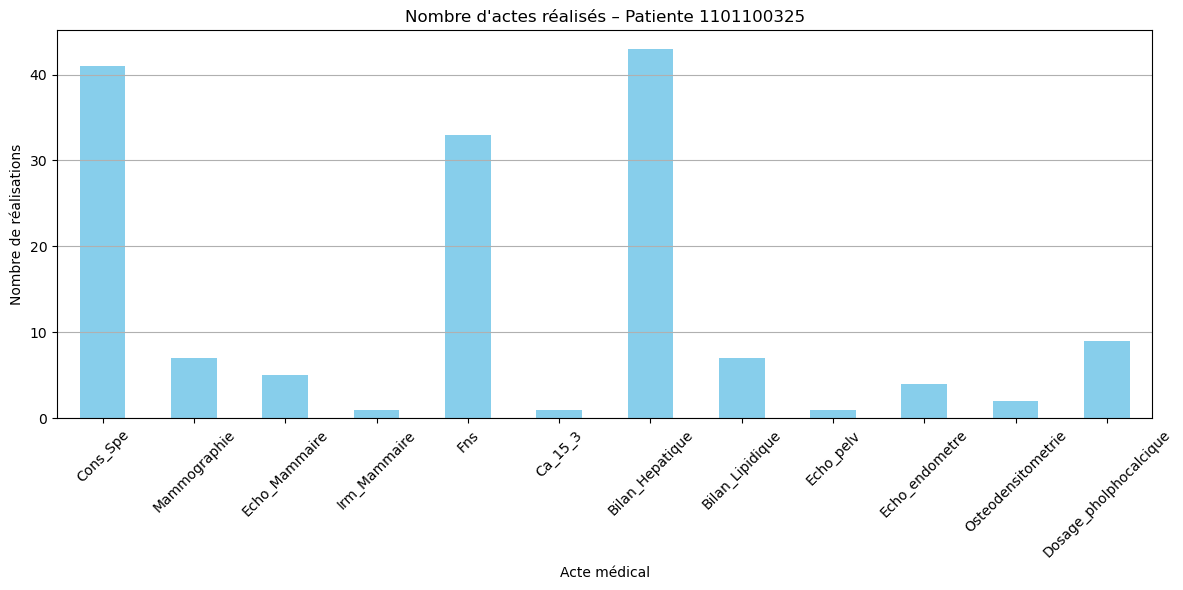

In [ ]:
import matplotlib.pyplot as plt

id_exemple = df_long["ID_PATIENT"].iloc[0]

df_patient = df_long[df_long["ID_PATIENT"] == id_exemple]

df_plot = df_patient.set_index("Acte")["Nb_realisations"]

plt.figure(figsize=(12, 6))
df_plot.plot(kind="bar", color="skyblue")
plt.title(f"Nombre d'actes réalisés – Patiente {id_exemple}")
plt.ylabel("Nombre de réalisations")
plt.xlabel("Acte médical")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [25]:
df_vecteurs = df_resumé_par_periode.copy()
df_vecteurs[actes_suivi] = (df_vecteurs[actes_suivi] > 0).astype(int)


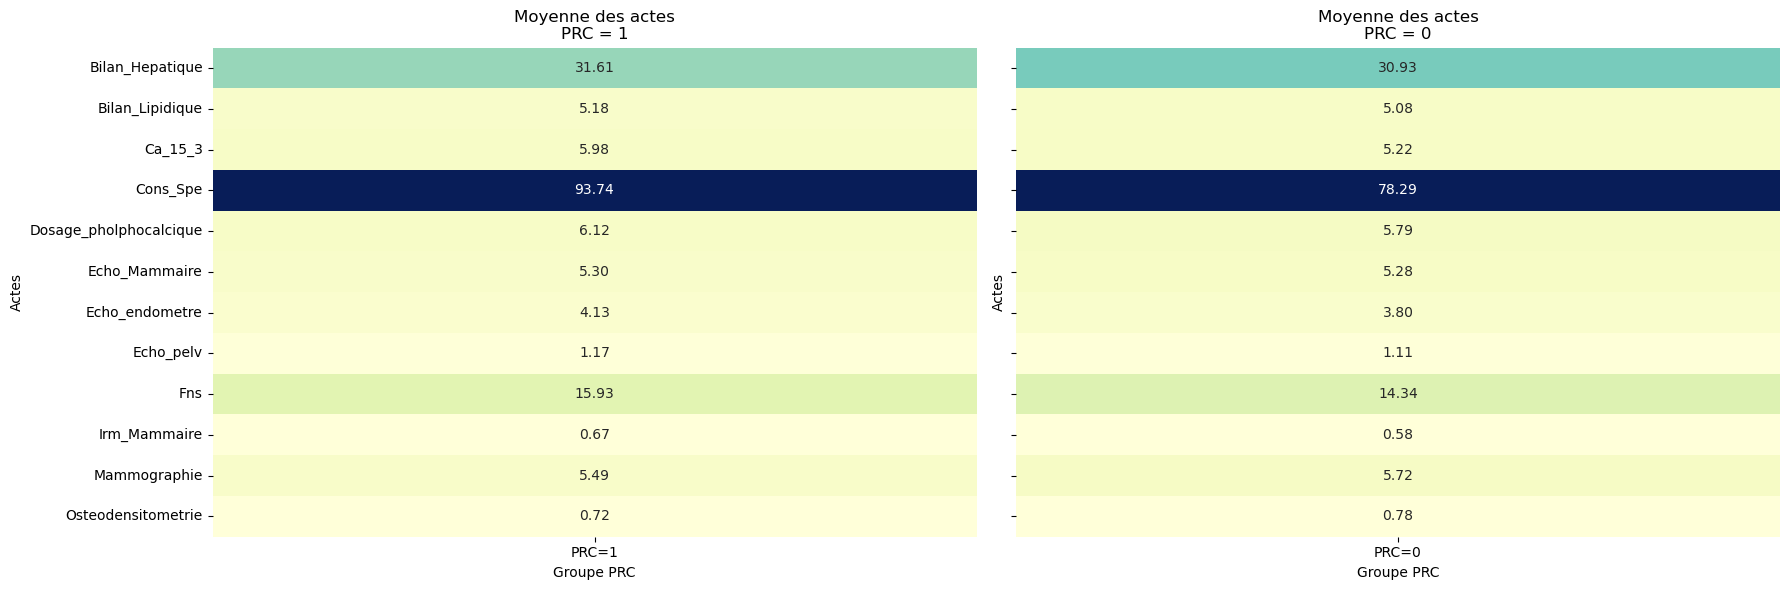

In [64]:
df_prc = df_merged[["ID_PATIENT", "PRC"]].drop_duplicates()
df_long = df_long.merge(df_prc, on="ID_PATIENT", how="left")
df_heatmap = df_long.groupby(["Acte", "PRC"])["Nb_realisations"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for prc_value, ax in zip([1, 0], axes):
    if prc_value in df_heatmap.columns:
        data = df_heatmap[[prc_value]].rename(columns={prc_value: f"PRC={prc_value}"})
        sns.heatmap(data, annot=True, cmap="YlGnBu", fmt=".2f", ax=ax, cbar=False)
        ax.set_title(f"Moyenne des actes\nPRC = {prc_value}")
        ax.set_xlabel("Groupe PRC")
        ax.set_ylabel("Actes")

plt.tight_layout()
plt.show()

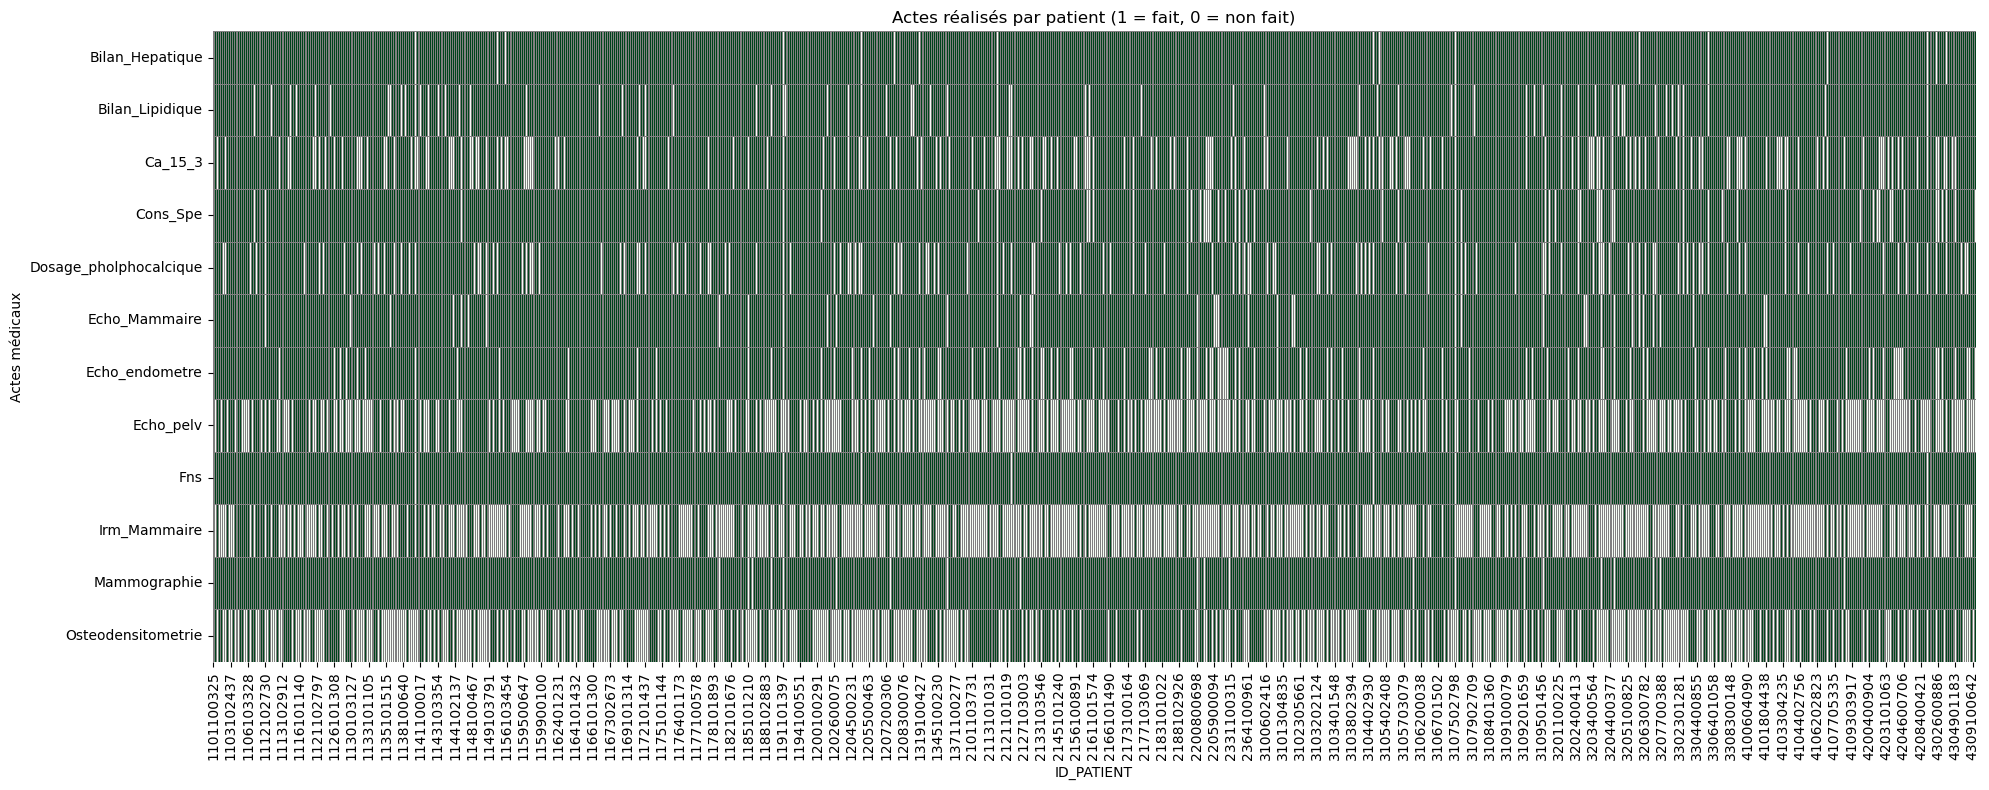

In [77]:
# Étape 1 : transformer en binaire
df_binaire = df_long.copy()
df_binaire["fait"] = (df_binaire["Nb_realisations"] > 0).astype(int)

# Étape 2 : pivot : lignes = actes, colonnes = patients
df_matrix = df_binaire.pivot(index="Acte", columns="ID_PATIENT", values="fait").fillna(0)

# Étape 3 : heatmap
plt.figure(figsize=(min(20, 0.3 * len(df_matrix.columns)), 8))  # auto-fit largeur
sns.heatmap(df_matrix, cmap="Greens", cbar=False, linewidths=0.5, linecolor='gray')

plt.title("Actes réalisés par patient (1 = fait, 0 = non fait)")
plt.xlabel("ID_PATIENT")
plt.ylabel("Actes médicaux")
plt.tight_layout()
plt.show()


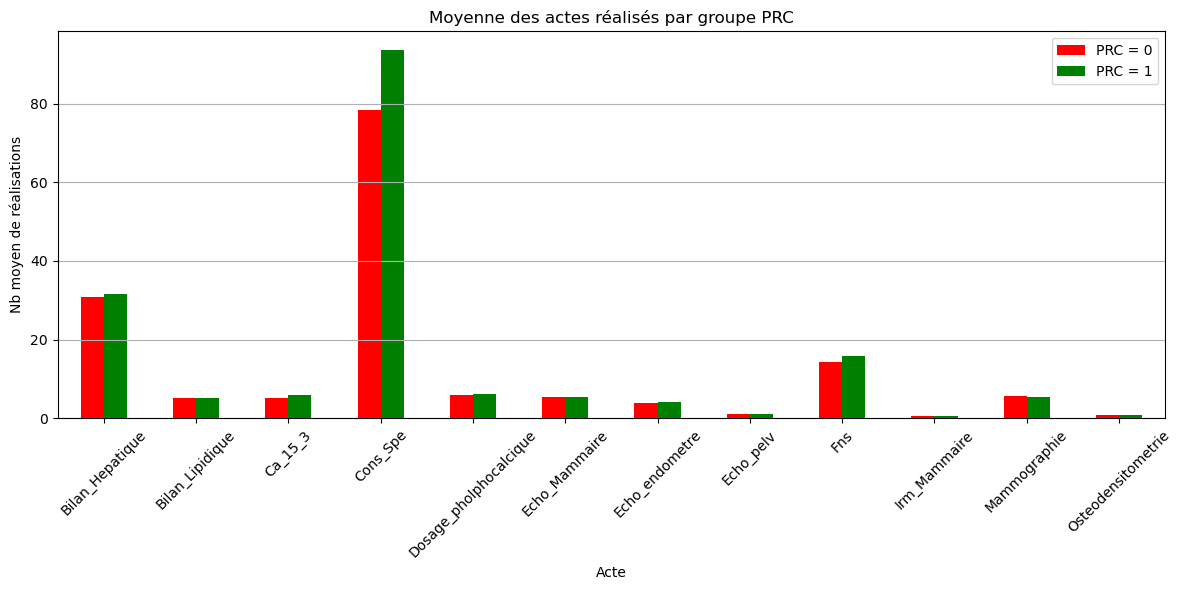

In [83]:
df_moyennes = df_long.groupby(["Acte", "PRC"])["Nb_realisations"].mean().unstack()
df_moyennes.plot(kind="bar", figsize=(12, 6), color=["red", "green"])
plt.title("Moyenne des actes réalisés par groupe PRC")
plt.ylabel("Nb moyen de réalisations")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(["PRC = 0", "PRC = 1"])
plt.tight_layout()
plt.show()


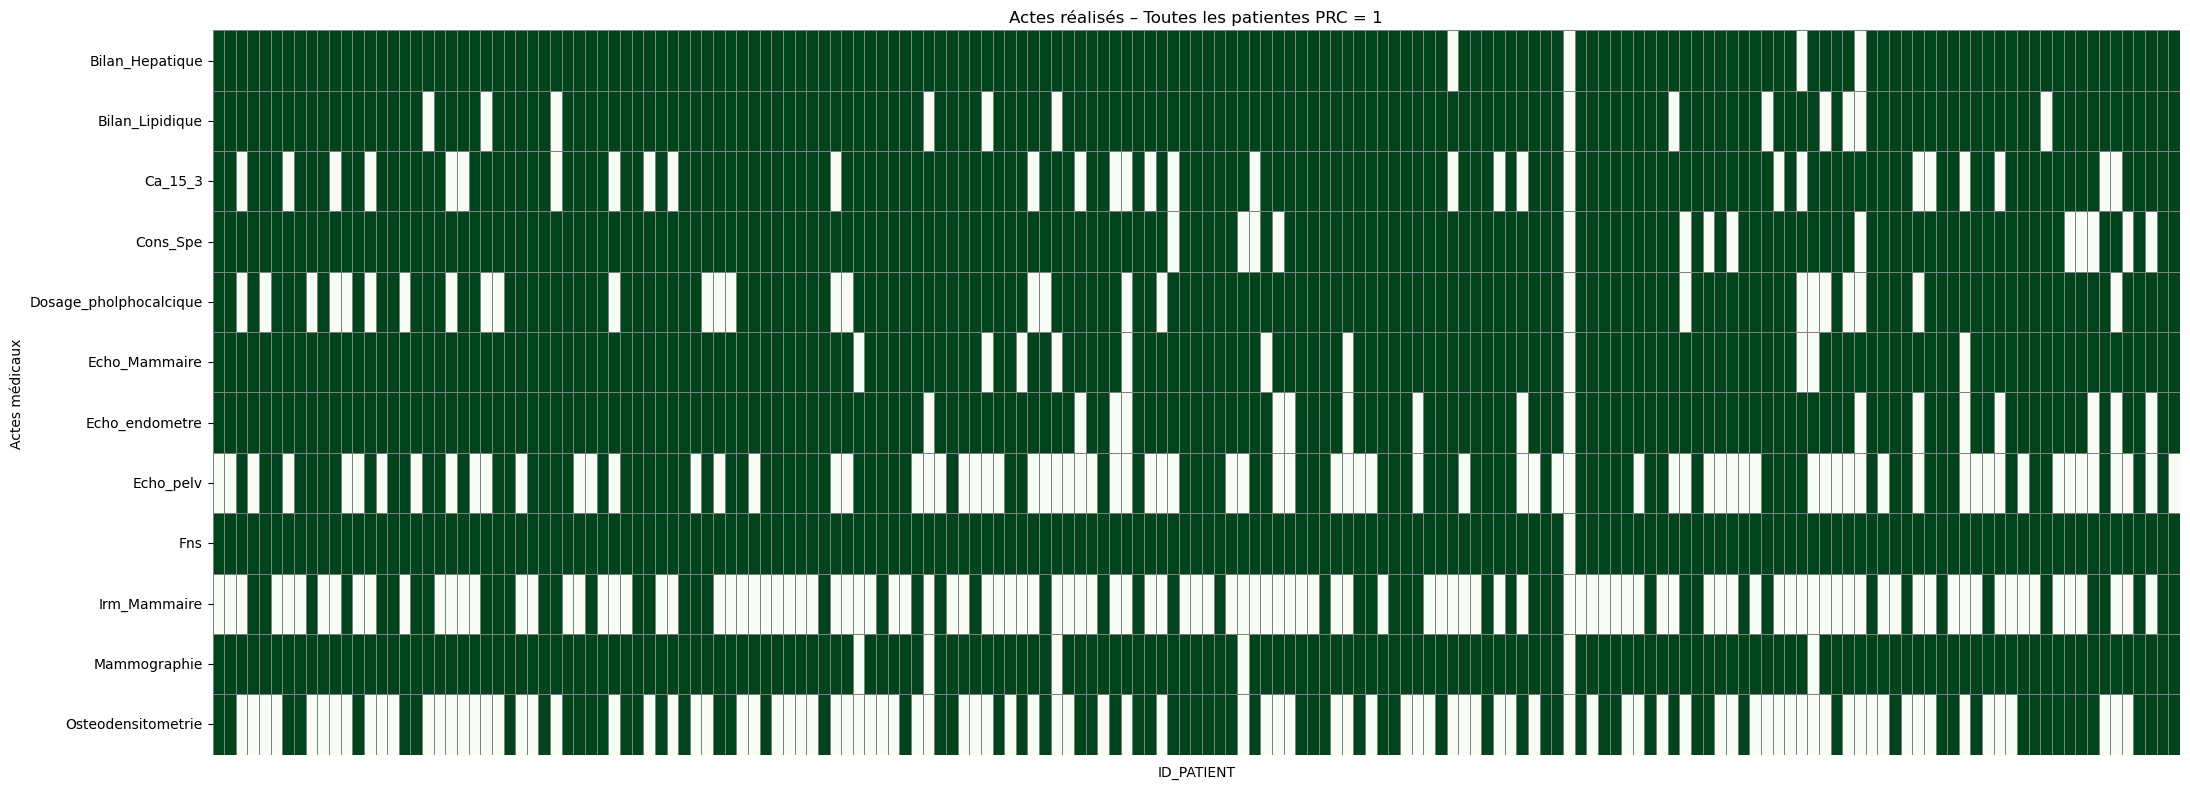

In [91]:
# PRC = 1
df_matrix_all = df_binaire.pivot(index="Acte", columns="ID_PATIENT", values="fait").fillna(0)

ids_prc1 = df_binaire[df_binaire["PRC"] == 1]["ID_PATIENT"].unique()
df_matrix_prc1 = df_matrix_all[[id_ for id_ in df_matrix_all.columns if id_ in ids_prc1]]

plt.figure(figsize=(min(22, 0.3 * len(df_matrix_prc1.columns)), 8))  # adapte la largeur
sns.heatmap(df_matrix_prc1, cmap="Greens", cbar=False, linewidths=0.5, linecolor='gray')
plt.title("Actes réalisés – Toutes les patientes PRC = 1")
plt.xlabel("ID_PATIENT")
plt.ylabel("Actes médicaux")
plt.xticks([], [])
plt.tight_layout()
plt.show()


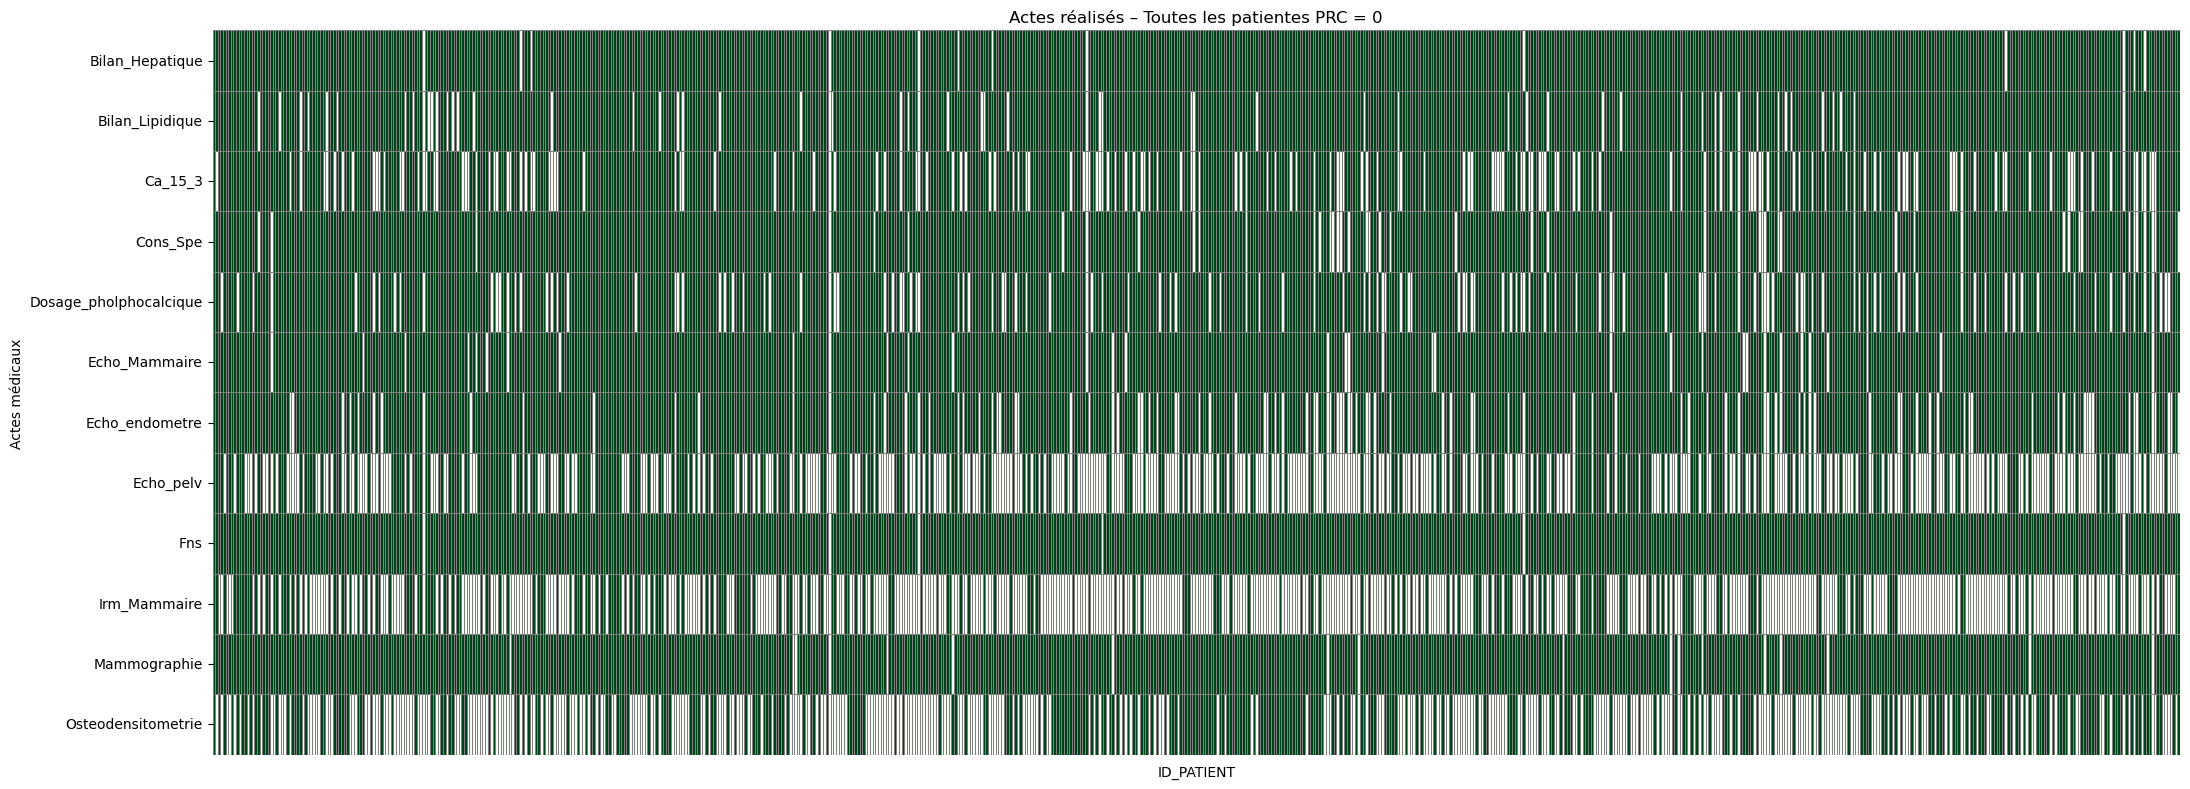

In [93]:
# PRC = 0
ids_prc0 = df_binaire[df_binaire["PRC"] == 0]["ID_PATIENT"].unique()
df_matrix_prc0 = df_matrix_all[[id_ for id_ in df_matrix_all.columns if id_ in ids_prc0]]

plt.figure(figsize=(min(22, 0.3 * len(df_matrix_prc0.columns)), 8))
sns.heatmap(df_matrix_prc0, cmap="Greens", cbar=False, linewidths=0.5, linecolor='gray')
plt.title("Actes réalisés – Toutes les patientes PRC = 0")
plt.xlabel("ID_PATIENT")
plt.ylabel("Actes médicaux")
plt.xticks([], [])
plt.tight_layout()
plt.show()


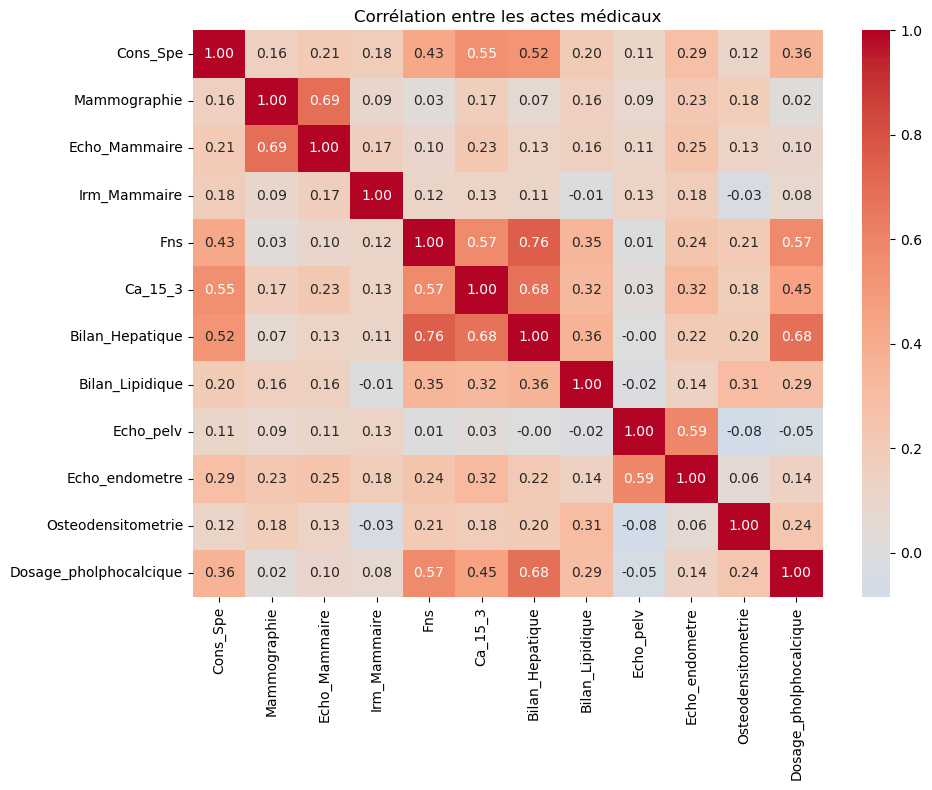

In [94]:
# Calcul de la corrélation entre les actes (quantité par patiente)
corr = df_counts[actes_suivi].corr()

# Affichage de la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Corrélation entre les actes médicaux")
plt.tight_layout()
plt.show()


## Etude de Conformité avec les recommendations du PSP

In [102]:
def calculer_conformité(row):
    freq = frequences_actes.get(row["Acte"])
    nb_realisations = row["Nb_realisations"]
    duree = row["duree_suivi_mois"]

    if freq is None:
        return None  # pas de fréquence définie
    elif isinstance(freq, list):  # ex : [0, 24] → actes ponctuels
        attendus = len([m for m in freq if m <= duree])
        return int(nb_realisations >= attendus)
    else:  # fréquence régulière tous les X mois
        attendus = max(1, int(duree // freq))  # au moins 1 exigé si duree >= freq
        return int(nb_realisations >= attendus)

# Appliquer sur chaque ligne du df_long
df_long["conforme"] = df_long.apply(calculer_conformité, axis=1)


In [103]:
df_long.head(20)

,ID_PATIENT,Acte,Nb_realisations,duree_suivi_mois,Frequence_mois,PRC,conforme,Tamoxifen_x,Anti_arom_x,CT_x,Tamoxifen_y,Anti_arom_y,CT_y
0,1101100325,Cons_Spe,41,81,3,0,1.0,0,1,1,0,1,1
1,1101100717,Cons_Spe,7,86,3,1,0.0,1,1,1,1,1,1
2,1101100766,Cons_Spe,19,78,3,0,0.0,0,0,0,0,0,0
3,1102100494,Cons_Spe,29,82,3,0,1.0,1,1,1,1,1,1
4,1102101103,Cons_Spe,93,84,3,1,1.0,1,0,1,1,0,1
5,1102101659,Cons_Spe,106,85,3,0,1.0,1,0,1,1,0,1
6,1102102186,Cons_Spe,94,82,3,1,1.0,1,1,1,1,1,1
7,1103100275,Cons_Spe,48,83,3,0,1.0,1,1,1,1,1,1
8,1103101510,Cons_Spe,55,84,3,0,1.0,0,0,1,0,0,1
9,1103102437,Cons_Spe,92,82,3,0,1.0,1,1,1,1,1,1


In [104]:
# 1. Calcul des traitements actifs par patiente depuis df_merged
traitements = df_merged.groupby("ID_PATIENT")[["Tamoxifen", "Anti_arom", "CT"]].max().reset_index()

# 2. Intégrer les colonnes Tamoxifen / Anti_arom / CT dans df_long
df_long = df_long.merge(traitements, on="ID_PATIENT", how="left")


                            PRC_0      PRC_1  Différence PRC1 - PRC_0
Cons_Spe                78.292943  93.739645                15.446702
Mammographie             5.716378   5.491124                -0.225254
Echo_Mammaire            5.275632   5.301775                 0.026143
Irm_Mammaire             0.581891   0.674556                 0.092665
Fns                     14.338216  15.928994                 1.590778
Ca_15_3                  5.222370   5.982249                 0.759878
Bilan_Hepatique         30.928096  31.609467                 0.681372
Bilan_Lipidique          5.075899   5.177515                 0.101616
Echo_pelv                1.598338   1.478261                -0.120077
Echo_endometre           4.747922   4.760870                 0.012947
Osteodensitometrie       1.414330   1.328947                -0.085383
Dosage_pholphocalcique   6.869159   8.684211                 1.815052


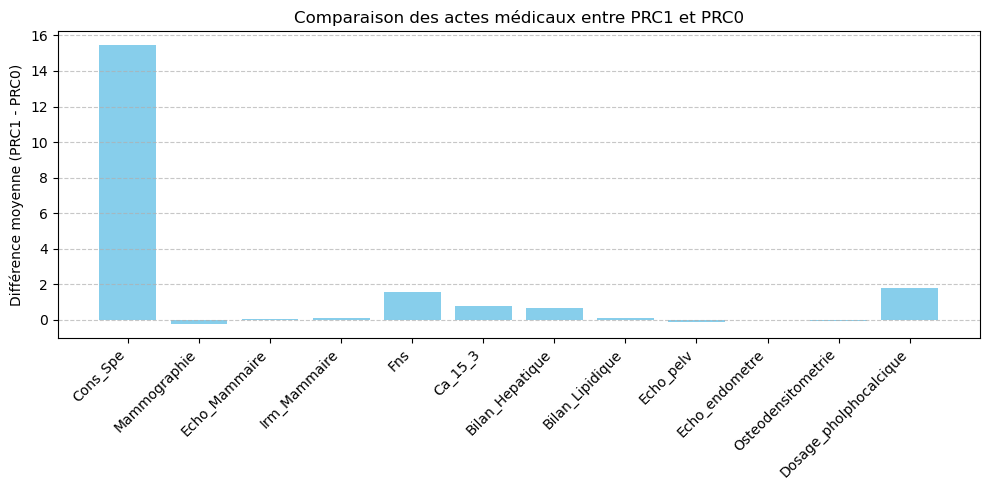

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Fonction adaptée à df_long
def moyenne_par_acte_conditionnelle_long(df_long, acte, condition_col=None):
    df_acte = df_long[df_long["Acte"] == acte]
    if condition_col:
        df_acte = df_acte[df_acte[condition_col] == 1]
    if df_acte.empty:
        return pd.DataFrame({f"PRC_0": [0], f"PRC_1": [0]}, index=[acte])
    
    moyennes = df_acte.groupby("PRC")["Nb_realisations"].mean().to_frame().T
    moyennes.columns = [f"PRC_{col}" for col in moyennes.columns]
    moyennes.index = [acte]
    return moyennes

# Dictionnaire des conditions spécifiques
actes_conditions = {
    "Cons_Spe": None,
    "Mammographie": None,
    "Echo_Mammaire": None,
    "Irm_Mammaire": None,
    "Fns": None,
    "Ca_15_3": None,
    "Bilan_Hepatique": None,
    "Bilan_Lipidique": None,
    "Echo_pelv": "Tamoxifen",
    "Echo_endometre": "Tamoxifen",
    "Osteodensitometrie": "Anti_arom",
    "Dosage_pholphocalcique": "Anti_arom"
}

# Calcul des moyennes
moyennes_finales = []
for acte, condition in actes_conditions.items():
    moy = moyenne_par_acte_conditionnelle_long(df_long, acte, condition)
    moyennes_finales.append(moy)

df_moyennes_pps = pd.concat(moyennes_finales)

# Ajouter la différence PRC_1 - PRC_0
df_moyennes_pps["Différence PRC1 - PRC_0"] = df_moyennes_pps["PRC_1"] - df_moyennes_pps["PRC_0"]

# Affichage tableau
print(df_moyennes_pps)

# Sankey
labels = list(df_moyennes_pps.index) + ["PRC_0", "PRC_1"]
sources, targets, values = [], [], []

for i, acte in enumerate(df_moyennes_pps.index):
    sources += [i, i]
    targets += [len(df_moyennes_pps.index), len(df_moyennes_pps.index)+1]
    values += [df_moyennes_pps.loc[acte, "PRC_0"], df_moyennes_pps.loc[acte, "PRC_1"]]

fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels, pad=15, thickness=20),
    link=dict(source=sources, target=targets, value=values)
)])
fig.show()

# Histogramme style "code initial"
plt.figure(figsize=(10, 5))
plt.bar(df_moyennes_pps.index, df_moyennes_pps["Différence PRC1 - PRC_0"], color="skyblue")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Différence moyenne (PRC1 - PRC0)")
plt.title("Comparaison des actes médicaux entre PRC1 et PRC0")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


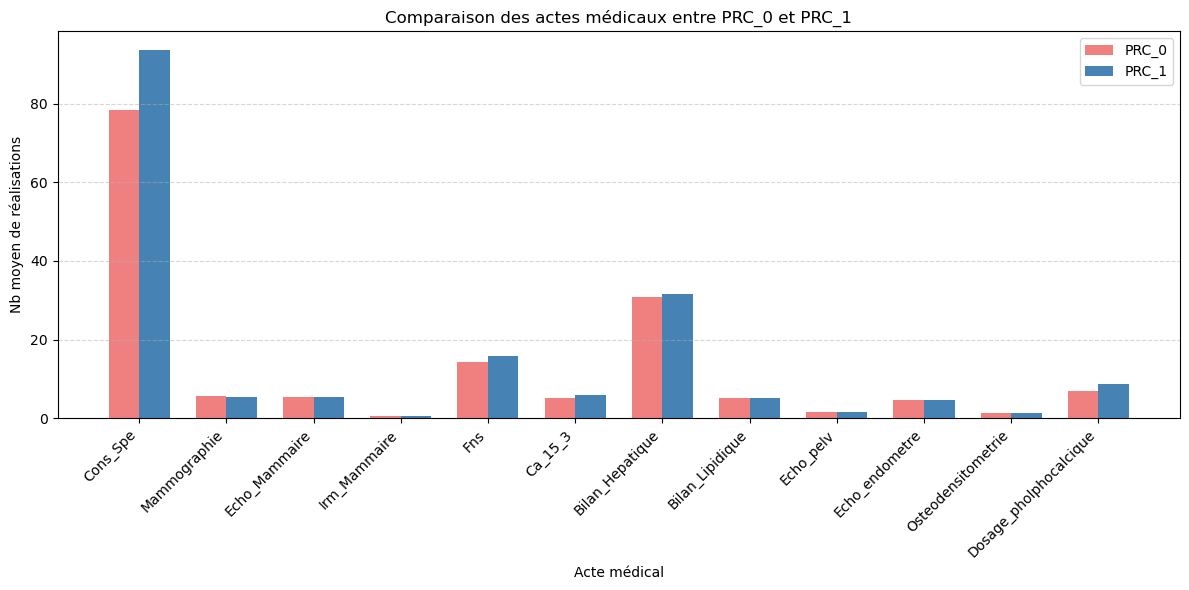

In [127]:
import matplotlib.pyplot as plt

# Histogramme côte à côte pour PRC_0 et PRC_1
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(df_moyennes_pps))

plt.bar(index, df_moyennes_pps["PRC_0"], bar_width, label="PRC_0", color='lightcoral')
plt.bar([i + bar_width for i in index], df_moyennes_pps["PRC_1"], bar_width, label="PRC_1", color='steelblue')

plt.xlabel("Acte médical")
plt.ylabel("Nb moyen de réalisations")
plt.title("Comparaison des actes médicaux entre PRC_0 et PRC_1")
plt.xticks([i + bar_width / 2 for i in index], df_moyennes_pps.index, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


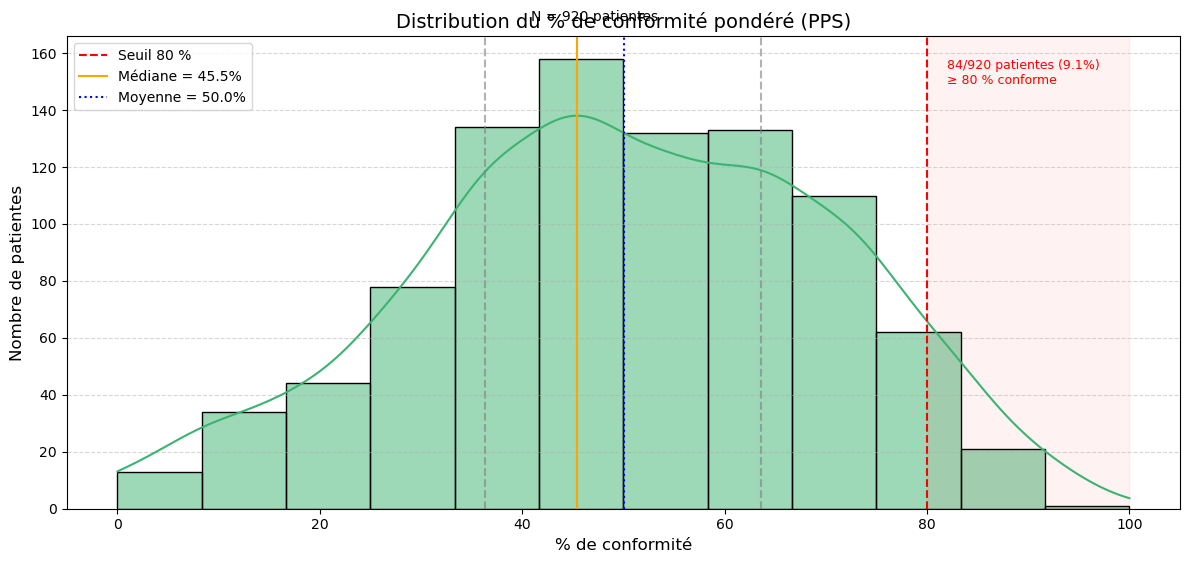

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcul du score de conformité par patient (en %)
df_scores = (
    df_long[~df_long["conforme"].isna()]
    .groupby("ID_PATIENT")["conforme"]
    .mean()
    .reset_index(name="pct_PPS_pondéré")
)
df_scores["pct_PPS_pondéré"] *= 100

# Statistiques descriptives
serie = df_scores["pct_PPS_pondéré"]
n = len(serie)
mean = serie.mean()
med = serie.median()
q1, q3 = serie.quantile([.25, .75])
n_ok = (serie >= 80).sum()

# Graphique
plt.figure(figsize=(12, 6))
sns.histplot(serie, bins=12, kde=True, color="mediumseagreen")

plt.axvline(80, ls="--", color="red", label="Seuil 80 %")
plt.axvline(med, ls="-", color="orange", label=f"Médiane = {med:.1f}%")
plt.axvline(mean, ls=":", color="blue", label=f"Moyenne = {mean:.1f}%")
plt.axvline(q1, ls="--", color="grey", alpha=.6)
plt.axvline(q3, ls="--", color="grey", alpha=.6)
plt.axvspan(80, 100, color="red", alpha=.05)

plt.text(82, plt.ylim()[1]*.9,
         f"{n_ok}/{n} patientes ({n_ok/n:.1%})\n≥ 80 % conforme",
         color="red", fontsize=9)

plt.title("Distribution du % de conformité pondéré (PPS)", fontsize=14)
plt.xlabel("% de conformité", fontsize=12)
plt.ylabel("Nombre de patientes", fontsize=12)
plt.suptitle(f"N = {n} patientes", y=0.93, fontsize=10)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


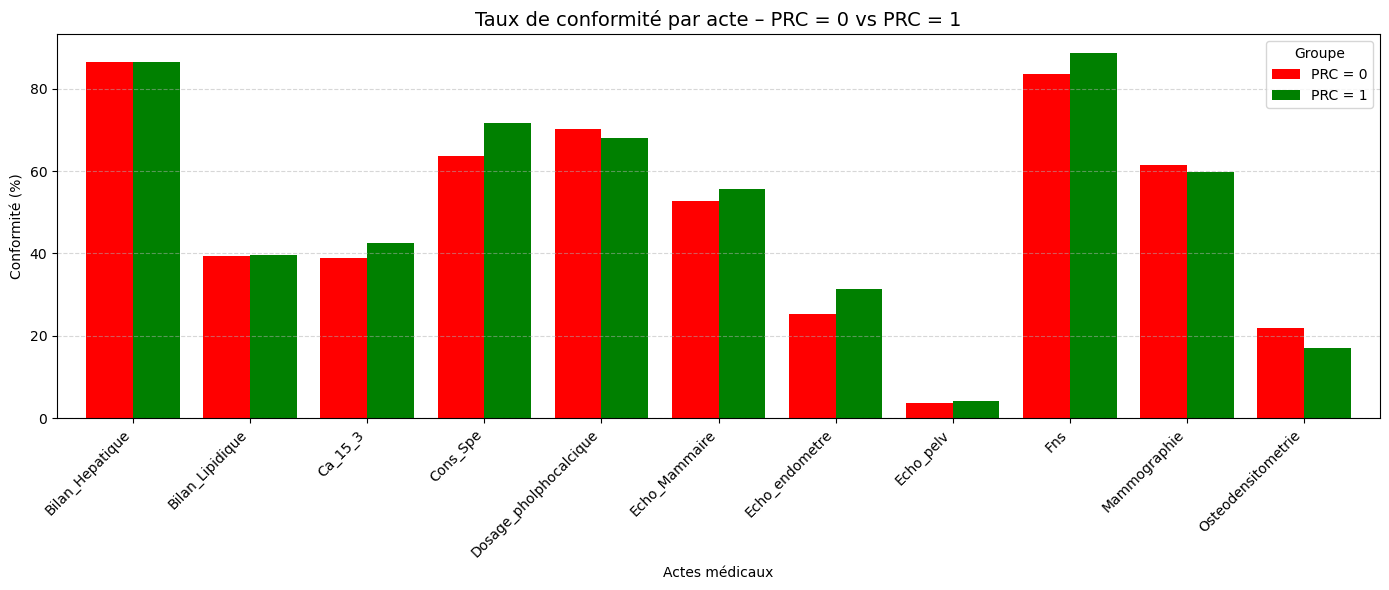

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcul du pourcentage de conformité par acte et PRC
df_conformite_pct = (
    df_long[~df_long["conforme"].isna()]
    .groupby(["Acte", "PRC"])["conforme"]
    .mean()
    .unstack()
    .fillna(0) * 100
)

# Affichage du barplot
ax = df_conformite_pct.plot(kind="bar", figsize=(14, 6), width=0.8, color=["red", "green"])
plt.title("Taux de conformité par acte – PRC = 0 vs PRC = 1", fontsize=14)
plt.ylabel("Conformité (%)")
plt.xlabel("Actes médicaux")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(["PRC = 0", "PRC = 1"], title="Groupe")
plt.tight_layout()
plt.show()


In [117]:
import pandas as pd, plotly.graph_objects as go
from itertools import chain

def sankey_from_df(df_links, title):
    if df_links.empty:
        print(f"⚠️  Aucune donnée pour {title}")
        return
    labels = pd.Index(sorted(set(chain(df_links["source"], df_links["target"]))), name="label")
    codes = {lab: i for i, lab in enumerate(labels)}
    df_num = df_links.replace({"source": codes, "target": codes})
    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(label=labels.tolist(), pad=15, thickness=15,
                  line=dict(color="black", width=0.5)),
        link=dict(source=df_num["source"], target=df_num["target"], value=df_num["value"])
    ))
    fig.update_layout(title_text=title, font_size=11, height=550, width=940)
    fig.show()


In [118]:
df_long["score_pct"] = df_long.groupby("ID_PATIENT")["conforme"].transform(lambda x: 100 * x.mean())
df_long["score_band"] = pd.cut(df_long["score_pct"], bins=[0, 20, 40, 60, 80, 100],
                               labels=["0-20 %", "20-40 %", "40-60 %", "60-80 %", "80-100 %"],
                               right=False)

links = (
    df_long.query("conforme == 1")
    .groupby(["Acte", "score_band"])
    .size()
    .reset_index(name="value")
    .rename(columns={"Acte": "source", "score_band": "target"})
)
sankey_from_df(links, "Actes ➜ score de conformité")


In [119]:
# 1. Mapping actes → famille
family_map = {
    "Cons_Spe": "Consultation",
    "Mammographie": "Imagerie",
    "Echo_Mammaire": "Imagerie",
    "Irm_Mammaire": "Imagerie",
    "Fns": "Biologie",
    "Ca_15_3": "Biologie",
    "Bilan_Hepatique": "Biologie",
    "Bilan_Lipidique": "Biologie",
    "Echo_pelv": "Gynécologie",
    "Echo_endometre": "Gynécologie",
    "Osteodensitometrie": "Ostéo",
    "Dosage_pholphocalcique": "Ostéo"
}

# 2. Associer chaque acte à une famille
df_long["Famille"] = df_long["Acte"].map(family_map)

# 3. Score de conformité
df_long["score_pct"] = df_long.groupby("ID_PATIENT")["conforme"].transform(lambda x: 100 * x.mean())
df_long["score_band"] = pd.cut(
    df_long["score_pct"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20 %", "20-40 %", "40-60 %", "60-80 %", "80-100 %"],
    right=False
)

# 4. Liens Famille ➜ Niveau de conformité
links_family = (
    df_long.query("conforme == 1")
           .groupby(["Famille", "score_band"])
           .size()
           .reset_index(name="value")
           .rename(columns={"Famille": "source", "score_band": "target"})
)

# 5. Affichage Sankey
sankey_from_df(links_family, "Familles d'actes ➜ score de conformité")


## En gros pour cette partie 

#### Le graphe orange montre que chaque trimestre est rarement complet (score 0 à 2 dominant),

#### Le graphe bleu montre que malgré cela, certaines patientes parviennent à cumulativement respecter 4 à 6 critères sur 5 ans, ce qui est logique.

## Traitement d'Excès d'actes médicaux 

In [ ]:
seuils_3mois = {
    "Cons_Med_Gen": 1,
    "Cons_Spe": 1,
    "Mammographie": 0.25,
    "Ca_15_3": 0.25,
    "Fns": 0.25,
    "Bilan_Hepatique": 0.25,
    "Bilan_Lipidique": 0.25,
    "Echo_pelv": 0.25  # Conditionnel
}


In [ ]:
for acte, seuil in seuils_3mois.items():
    col_name = f"excès_{acte}"
    if acte == "Echo_pelv":
        # Cas conditionnel : uniquement si Tamoxifen == 1
        df_resumé_par_periode[col_name] = df_resumé_par_periode.apply(
            lambda row: 1 if row["Tamoxifen"] == 1 and row.get(acte, 0) > seuil else 0, axis=1
        )
    elif acte in df_resumé_par_periode.columns:
        df_resumé_par_periode[col_name] = (df_resumé_par_periode[acte] > seuil).astype(int)
    else:
        df_resumé_par_periode[col_name] = 0  # si l'acte est absent


In [ ]:
colonnes_excès = [f"excès_{acte}" for acte in seuils_3mois.keys()]
df_resumé_par_periode["score_excès"] = df_resumé_par_periode[colonnes_excès].sum(axis=1)


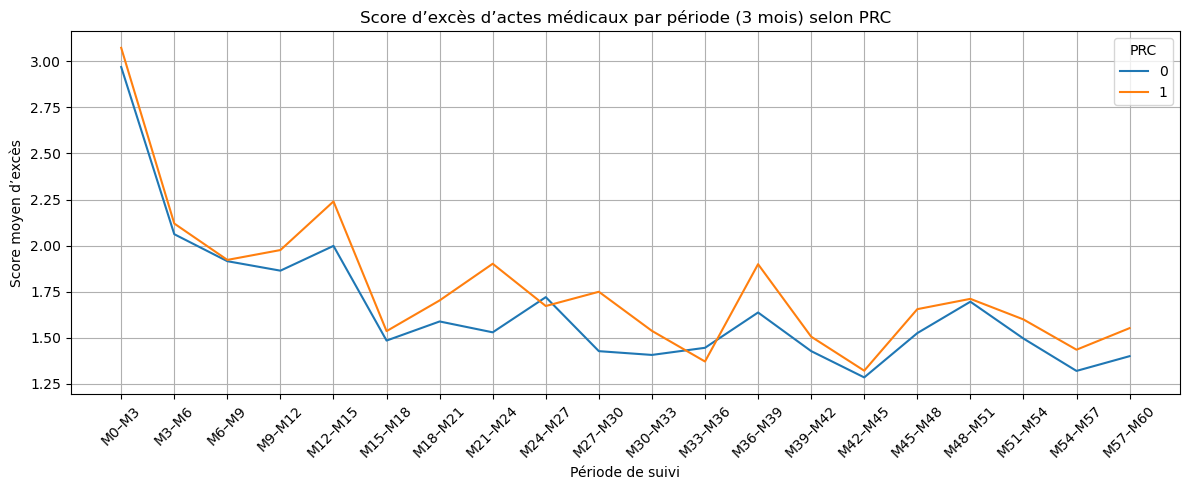

In [ ]:
périodes_valides = [x for x in df_resumé_par_periode["periode_suivi"].dropna().unique() if "60+" not in x]

ordre = sorted(périodes_valides, key=lambda x: int(x[1:].split("–")[0]))

if "M60+" in df_resumé_par_periode["periode_suivi"].values:
    ordre.append("M60+")

df_resumé_par_periode["periode_suivi"] = pd.Categorical(df_resumé_par_periode["periode_suivi"], categories=ordre, ordered=True)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_resumé_par_periode[df_resumé_par_periode["periode_suivi"] != "M60+"],
    x="periode_suivi",
    y="score_excès",
    hue="PRC",
    estimator="mean",
    ci=None
)
plt.title("Score d’excès d’actes médicaux par période (3 mois) selon PRC")
plt.xlabel("Période de suivi")
plt.ylabel("Score moyen d’excès")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import shapiro

groupe_0 = df_resumé_par_periode[df_resumé_par_periode["PRC"] == 0]["score_excès"]
groupe_1 = df_resumé_par_periode[df_resumé_par_periode["PRC"] == 1]["score_excès"]

# Tester la normalité
stat0, p0 = shapiro(groupe_0.sample(500, random_state=1))
stat1, p1 = shapiro(groupe_1.sample(500, random_state=1))

print(f"Shapiro PRC = 0: p = {p0:.4f}")
print(f"Shapiro PRC = 1: p = {p1:.4f}")


stat, p = mannwhitneyu(groupe_0, groupe_1, alternative='two-sided')
print(f"Mann-Whitney U Test : U = {stat}, p-value = {p:.4f}")



Shapiro PRC = 0: p = 0.0000
Shapiro PRC = 1: p = 0.0000
Mann-Whitney U Test : U = 24101651.5, p-value = 0.0003


In [ ]:
print("Médiane PRC = 0 :", groupe_0.median())
print("Médiane PRC = 1 :", groupe_1.median())


Médiane PRC = 0 : 1.0
Médiane PRC = 1 : 1.0


### Pourquoi le score d’excès ?

Le score d’excès synthétise le nombre d’actes réalisés au-delà des seuils recommandés par le protocole PPS. Il permet d’identifier une possible surmédicalisation. Nous l’avons utilisé pour évaluer si le statut PRC est associé à un suivi potentiellement plus intensif que recommandé.

### Choix du test

Le test de Shapiro-Wilk montre que `score_excès` ne suit pas une distribution normale. Par conséquent, nous utilisons le test de Mann-Whitney U pour Évaluer si l'une des deux distributions tend à produire des valeurs plus grandes que l'autre.



### Résultat

- U = 24,101,651.5
- p-value = 0.0003

Cela indique une différence statistiquement significative dans la distribution du score d’excès selon le PRC. Les patientes avec PRC ont tendance à avoir un suivi plus intensif.


Silhouette (k=4) : 0.435

Effectifs par cluster :
0    583
1    321
2     10
3      6
Name: cluster, dtype: int64 

Profil moyen (% actes réalisés) :


,conf_Irm_Mammaire,conf_Cons_Spe,conf_Mammographie,conf_Echo_Mammaire,conf_Ca_15_3,conf_Fns,conf_Bilan_Hepatique,conf_Bilan_Lipidique,conf_Echo_pelv,conf_Echo_endometre,conf_Osteodensitometrie,conf_Dosage_pholphocalcique
cluster,,,,,,,,,,,,
0,2.4,75.3,53.0,93.1,3.6,8.2,1.9,1.7,0.0,2.6,0.0,2.6
1,3.3,86.9,62.3,98.1,55.1,93.5,88.5,33.0,0.0,9.7,0.0,18.7
2,5.7,90.0,70.0,100.0,50.0,50.0,30.0,0.0,100.0,100.0,0.0,10.0
3,2.4,83.3,83.3,100.0,50.0,50.0,66.7,50.0,0.0,0.0,100.0,16.7


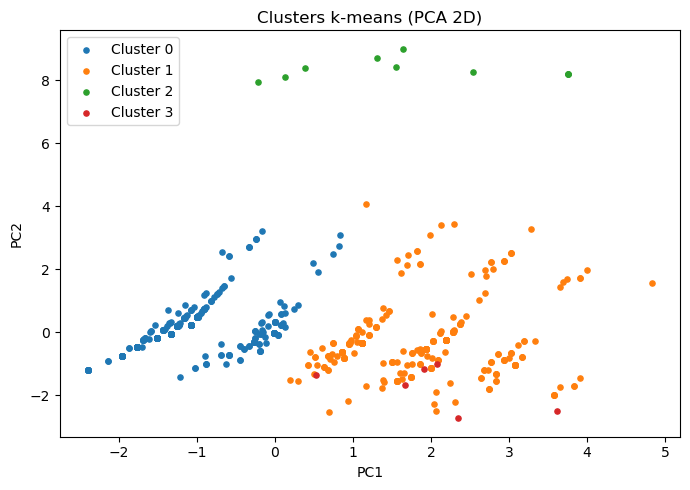

In [87]:
# ──────────────────────────────────────────────────────────────
# 0) Imports
# ──────────────────────────────────────────────────────────────
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# ──────────────────────────────────────────────────────────────
# 1) Matrice % actes réalisés / patiente
# ──────────────────────────────────────────────────────────────
acts   = [c for c in df.columns if c.startswith("conf_")]   # colonnes 0/1
X_pct  = df.groupby("ID_PATIENT")[acts].mean() * 100        # 0-100 %

# ──────────────────────────────────────────────────────────────
# 2) Standardisation
# ──────────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_pct)

# ──────────────────────────────────────────────────────────────
# 3) PCA : 5 axes pour le modèle, 2 axes pour le plot
# ──────────────────────────────────────────────────────────────
pca_5  = PCA(n_components=5, random_state=42)
X_pca5 = pca_5.fit_transform(X_scaled)

pca_2  = PCA(n_components=2, random_state=42)
X_pca2 = pca_2.fit_transform(X_scaled)

# ──────────────────────────────────────────────────────────────
# 4) k-means
# ──────────────────────────────────────────────────────────────
k = 4                         # ← change si besoin
kmeans  = KMeans(n_clusters=k, random_state=42, n_init=10)
labels  = kmeans.fit_predict(X_pca5)

print(f"Silhouette (k={k}) : {silhouette_score(X_pca5, labels):.3f}")

# ──────────────────────────────────────────────────────────────
# 5) Profil des clusters
# ──────────────────────────────────────────────────────────────
clusters = X_pct.copy()
clusters["cluster"] = labels

counts  = clusters["cluster"].value_counts().sort_index()
profile = clusters.groupby("cluster").mean().round(1)

print("\nEffectifs par cluster :")
print(counts, "\n")
print("Profil moyen (% actes réalisés) :")
display(profile)

# ──────────────────────────────────────────────────────────────
# 6) Visualisation 2D (PC1-PC2)
# ──────────────────────────────────────────────────────────────
plt.figure(figsize=(7,5))
palette = sns.color_palette("tab10", k)
for c in range(k):
    plt.scatter(X_pca2[labels==c,0], X_pca2[labels==c,1],
                s=14, color=palette[c], label=f"Cluster {c}")
plt.title("Clusters k-means (PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()


| Cluster (effectif) | Profil dominant                                                                                       | Lecture clinique rapide                                                                                                                                                   |
| ------------------ | ----------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **0 (583)**        | **Consult 75 %** · Mammo 53 % · **Écho mammaire 93 %**<br>Biologie < 10 % · Gynéco/Ostéo \~ 0 %       | **Suivi “noyau dur” seulement**. Les patientes font l’imagerie mammaire et voient le spécialiste, mais négligent systématiquement les bilans sanguins et actes adjuvants. |
| **1 (321)**        | **Consult 87 %** · **Écho 98 %** · Mammo 62 %<br>Biologie **55-94 %** · Lipides 33 % · Endomètre 10 % | **Suivi large mais inégal**. Presque tout le cœur du PPS est fait ; il manque surtout les examens secondaires (lipides, écho pelvienne).                                  |
| **2 (10)**         | **Consult 90 %** · **Écho 100 %** · Mammo 70 %<br>Écho pelv 100 % · Endomètre 100 %                   | **Ultra-conforme “Gynéco complet”**. Petit groupe, probablement patientes sous tamoxifène suivies par gynécologue dédié.                                                  |
| **3 (6)**          | **Mammo 83 %** · **Écho 100 %** · Osteodensito 100 %<br>Biologie 50-66 %                              | **Spécifique “Ostéo”**. Suivi anti-aromatase : ostéodensito systématique mais peu d’examens gynéco.                                                                       |


| Élément affiché | Ce que c’est                                                                                                 | Comment on l’obtient                                |
| --------------- | ------------------------------------------------------------------------------------------------------------ | --------------------------------------------------- |
| **PC1 (axe x)** | Combinaison linéaire de **tous** les actes `conf_*` qui explique la plus grande part de variance (≈ 40-50 %) | 1ʳᵉ colonne de la matrice des composantes de la PCA |
| **PC2 (axe y)** | Seconde combinaison, orthogonale à PC1, 2ᵉ plus forte variance (≈ 15-25 %)                                   | 2ᵉ colonne de la même matrice                       |
